# Evaluation notebook

This notebook evaluates the pre-trained model for early warning of incident events in the SMD dataset group1 machines.

In [23]:
from __future__ import annotations

import json
import math
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import load as joblib_load
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
)

In [24]:
PROCESSED_DIR = Path("../data/processed/smd_group1")
ART_DIR = Path("../artifacts/final_rf_group1")
MODEL_PATH = ART_DIR / "rf_final_W25_H5.joblib"
META_PATH = ART_DIR / "rf_final_W25_H5.json"

TARGET_INCIDENT_RECALL = 0.80
THRESH_GRID_SIZE = 301 
PLOT_CONTEXT = 300
RNG = np.random.default_rng(2026)
CALIB_USE_TUNED_TREES = False

In [25]:
def load_machines(processed_dir: Path) -> dict[str, pd.DataFrame]:
    csv_paths = sorted(processed_dir.glob("machine-1-*.csv"))
    if not csv_paths:
        raise FileNotFoundError(
            f"No machine-1-*.csv under: {processed_dir.resolve()}"
        )

    machines: dict[str, pd.DataFrame] = {}
    for p in csv_paths:
        df = pd.read_csv(p)
        if "label" not in df.columns:
            raise ValueError(f"Missing label in {p.name}")
        df["label"] = df["label"].astype(int)
        machines[p.stem] = df

    # Consistency check
    names = list(machines.keys())
    base = [c for c in machines[names[0]].columns if c != "label"]
    for n in names[1:]:
        cols = [c for c in machines[n].columns if c != "label"]
        if cols != base:
            raise ValueError(f"Feature columns mismatch in {n}")

    return machines

machines = load_machines(PROCESSED_DIR)

In [26]:
final_model = joblib_load(MODEL_PATH)
with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

W = int(meta["W"])
H = int(meta["H"])
TRAIN_FRAC = float(meta["train_frac"])
VAL_FRAC = float(meta["val_frac_within_train"])

final_params: dict[str, Any] = dict(meta["params"])
n_estimators_tuned = int(meta["n_estimators_tuned"])
n_estimators_final = int(meta["n_estimators_final"])

print("Loaded final model:", type(final_model).__name__)
print("W, H:", W, H)
print("n_estimators_tuned:", n_estimators_tuned)
print("n_estimators_final:", n_estimators_final)

Loaded final model: RandomForestClassifier
W, H: 25 5
n_estimators_tuned: 400
n_estimators_final: 800


## Feature engineering
Each machine timeline is converted into supervised samples in the exact same way as in the training process.

In [27]:
# Converts a single machine timeline into supervised samples
def create_supervised_dataset(df: pd.DataFrame, window_size: int, horizon: int):
    
    if "label" not in df.columns:
        raise ValueError("Expected 'label' column in df")

    feature_df = df.drop(columns=["label"])
    labels = df["label"].astype(int).to_numpy()
    X_raw = feature_df.to_numpy()

    X_list = []
    y_list = []
    t_end_list = []

    for t in range(window_size, len(X_raw) - horizon):
        window = X_raw[t - window_size : t]

        w_mean = np.mean(window, axis=0)
        w_std = np.std(window, axis=0)
        w_delta = window[-1] - window[-2]

        with np.errstate(divide="ignore", invalid="ignore"):
            w_zscore = (window[-1] - w_mean) / w_std
        w_zscore = np.nan_to_num(w_zscore, nan=0.0, posinf=0.0, neginf=0.0)

        features_vector = np.concatenate([w_mean, w_std, w_delta, w_zscore])

        future_window = labels[t : t + horizon]
        incident_soon = 1 if future_window.sum() > 0 else 0

        X_list.append(features_vector)
        y_list.append(incident_soon)
        t_end_list.append(t)

    return np.array(X_list), np.array(y_list), np.array(t_end_list)

In [28]:
@dataclass(frozen=True)
class MachineEvalSplit:
    name: str
    df: pd.DataFrame
    feature_cols: list[str]
    gap: int

    cut_train_end: int
    cut_val_start: int

    X_tr: np.ndarray
    y_tr: np.ndarray
    t_tr: np.ndarray

    X_val: np.ndarray
    y_val: np.ndarray
    t_val: np.ndarray

    X_te: np.ndarray
    y_te: np.ndarray
    t_te: np.ndarray


def split_machine_for_eval(
    name: str,
    df: pd.DataFrame,
    window_size: int,
    horizon: int,
    train_frac: float,
    val_frac_within_train: float,
    dtype=np.float32,
) -> MachineEvalSplit:
    gap = window_size + horizon

    X, y, t_end = create_supervised_dataset(
        df=df,
        window_size=window_size,
        horizon=horizon,
    )

    n = len(df)
    cut_train_end = int(n * train_frac)
    cut_val_start = int(cut_train_end * (1 - val_frac_within_train))

    tr_mask = t_end < cut_val_start
    val_mask = (t_end >= cut_val_start + gap) & (t_end < cut_train_end)
    te_mask = t_end >= cut_train_end + gap

    X_tr, y_tr, t_tr = X[tr_mask], y[tr_mask], t_end[tr_mask]
    X_val, y_val, t_val = X[val_mask], y[val_mask], t_end[val_mask]
    X_te, y_te, t_te = X[te_mask], y[te_mask], t_end[te_mask]

    if len(X_tr) == 0 or len(X_val) == 0 or len(X_te) == 0:
        raise ValueError(
            f"Empty split for {name}. "
            f"len(tr)={len(X_tr)} len(val)={len(X_val)} len(te)={len(X_te)}"
        )

    feature_cols = [c for c in df.columns if c != "label"]

    return MachineEvalSplit(
        name=name,
        df=df,
        feature_cols=feature_cols,
        gap=gap,
        cut_train_end=cut_train_end,
        cut_val_start=cut_val_start,
        X_tr=X_tr.astype(dtype, copy=False),
        y_tr=y_tr.astype(np.int8, copy=False),
        t_tr=t_tr.astype(int),
        X_val=X_val.astype(dtype, copy=False),
        y_val=y_val.astype(np.int8, copy=False),
        t_val=t_val.astype(int),
        X_te=X_te.astype(dtype, copy=False),
        y_te=y_te.astype(np.int8, copy=False),
        t_te=t_te.astype(int),
    )


splits: dict[str, MachineEvalSplit] = {
    name: split_machine_for_eval(
        name=name,
        df=df,
        window_size=W,
        horizon=H,
        train_frac=TRAIN_FRAC,
        val_frac_within_train=VAL_FRAC,
    )
    for name, df in machines.items()
}

any_split = next(iter(splits.values()))
n_base = len(any_split.feature_cols)
expected_dim = 4 * n_base
assert any_split.X_tr.shape[1] == expected_dim, (
    any_split.X_tr.shape[1],
    expected_dim,
)

print("Feature dim:", expected_dim, f"(base={n_base}, engineered=4x)")
print(
    "Pooled sizes:",
    "train",
    sum(len(s.X_tr) for s in splits.values()),
    "val",
    sum(len(s.X_val) for s in splits.values()),
    "test",
    sum(len(s.X_te) for s in splits.values()),
)

# pooled arrays (window-level metrics)
X_tr_all = np.concatenate([s.X_tr for s in splits.values()], axis=0)
y_tr_all = np.concatenate([s.y_tr for s in splits.values()], axis=0)
X_val_all = np.concatenate([s.X_val for s in splits.values()], axis=0)
y_val_all = np.concatenate([s.y_val for s in splits.values()], axis=0)
X_te_all = np.concatenate([s.X_te for s in splits.values()], axis=0)
y_te_all = np.concatenate([s.y_te for s in splits.values()], axis=0)

print("val pos rate:", float(y_val_all.mean()))
print("test pos rate:", float(y_te_all.mean()))

Feature dim: 144 (base=36, engineered=4x)
Pooled sizes: train 108644 val 26974 test 58036
val pos rate: 0.09850226143693927
test pos rate: 0.0882555655110621


## Incident representation from raw labels

Window-level labels (`incident_soon`) are useful for training, but operationally, incident episodes are important.

Functions below help we convert raw `label == 1` segments into continuous incident intervals.

In [29]:
def find_intervals(labels: np.ndarray) -> list[tuple[int, int]]:
    out: list[tuple[int, int]] = []
    in_run = False
    start = 0
    for i, v in enumerate(labels):
        if v == 1 and not in_run:
            in_run = True
            start = i
        if v == 0 and in_run:
            out.append((start, i - 1))
            in_run = False
    if in_run:
        out.append((start, len(labels) - 1))
    return out


def intervals_starting_in_range(
    intervals: list[tuple[int, int]],
    start: int,
    end_exclusive: int,
) -> list[tuple[int, int]]:
    return [(a, b) for (a, b) in intervals if start <= a < end_exclusive]


@dataclass(frozen=True)
class IncidentEval:
    n_incidents: int
    n_caught: int
    recall: float
    lead_times: list[int]
    missed: list[tuple[int, int]]
    caught: list[tuple[int, int]]

## Incident-level evaluation 

Goal: measure whether the system gives an alert sufficiently close before an incident begins.

For each incident interval `(start, end)` whose start is inside the eval range:
- I consider an incident caught if there exists an alert time `t` in [start - H\; start)

I also compute:
- incident recall = caught / total incidents
- lead time for caught incidents = `start - first_alert_time`
- lists of caught/missed intervals for later failure analysis

In [30]:
def incident_level_eval_strict(
    split: MachineEvalSplit,
    proba: np.ndarray,
    t_pred: np.ndarray,
    threshold: float,
    which: str,
    horizon: int,
) -> IncidentEval:

    labels = split.df["label"].to_numpy(dtype=int)
    intervals_all = find_intervals(labels)

    if which == "val":
        eval_start = int(split.cut_val_start + split.gap)
        eval_end = int(split.cut_train_end)
    elif which == "test":
        eval_start = int(split.cut_train_end + split.gap)
        eval_end = int(len(labels))
    else:
        raise ValueError("which must be 'val' or 'test'")

    intervals = intervals_starting_in_range(intervals_all, eval_start, eval_end)

    alert_mask = proba >= threshold
    alert_times = t_pred[alert_mask]

    caught: list[tuple[int, int]] = []
    missed: list[tuple[int, int]] = []
    lead_times: list[int] = []

    for (start, end) in intervals:
        lo = start - horizon
        hi = start  
        valid_alerts = alert_times[(alert_times >= lo) & (alert_times <= hi)]
        if len(valid_alerts) > 0:
            first_alert = int(valid_alerts.min())
            caught.append((start, end))
            lead_times.append(start - first_alert)
        else:
            missed.append((start, end))

    n_inc = len(intervals)
    n_caught = len(caught)
    rec = (n_caught / n_inc) if n_inc > 0 else float("nan")

    return IncidentEval(
        n_incidents=int(n_inc),
        n_caught=int(n_caught),
        recall=float(rec),
        lead_times=lead_times,
        missed=missed,
        caught=caught,
    )

## Select an alert threshold on validation

I choose a probability threshold `thr` using a sweep over candidate thresholds derived from validation prediction quantiles.

For each candidate threshold:
- I compute pooled incident-level recall across all machines on validation.
- I compute pooled window precision/recall as secondary metrics (tie-breakers).

Selection rule:
- Prefer thresholds that achieve `incident_recall >= 0.8`
- Among feasible thresholds, pick the one with the best window precision

This produces:
- `thr_table`: a table of threshold vs. metrics
- `threshold`: the chosen operating point used for test evaluation

In [31]:
def select_threshold_on_val(
    splits: dict[str, MachineEvalSplit],
    final_model_: RandomForestClassifier,
    target_incident_recall: float,
    grid_size: int = 301,
) -> tuple[pd.DataFrame, float]:
    proba_all = []
    per_machine_pred: dict[str, dict[str, np.ndarray]] = {}

    for name, s in splits.items():
        p = final_model_.predict_proba(s.X_val)[:, 1].astype(float)
        per_machine_pred[name] = {"proba": p, "y": s.y_val.astype(int), "t": s.t_val}
        proba_all.append(p)

    proba_all_np = np.concatenate(proba_all)
    qs = np.linspace(0, 1, grid_size)
    thresholds = np.unique(np.quantile(proba_all_np, qs))
    thresholds = np.clip(thresholds, 0.0, 1.0)

    rows: list[dict[str, float]] = []
    for thr in thresholds:
        n_inc = 0
        n_caught = 0
        lead_times: list[int] = []

        y_pool = []
        p_pool = []

        for name, s in splits.items():
            p = per_machine_pred[name]["proba"]
            t = per_machine_pred[name]["t"]
            y = per_machine_pred[name]["y"]

            inc = incident_level_eval_strict(
                split=s,
                proba=p,
                t_pred=t,
                threshold=float(thr),
                which="val",
                horizon=H,
            )
            n_inc += inc.n_incidents
            n_caught += inc.n_caught
            lead_times.extend(inc.lead_times)

            y_pool.append(y)
            p_pool.append(p)

        y_pool_np = np.concatenate(y_pool)
        p_pool_np = np.concatenate(p_pool)
        yhat = (p_pool_np >= thr).astype(int)

        win_prec = precision_score(y_pool_np, yhat, zero_division=0)
        win_rec = recall_score(y_pool_np, yhat, zero_division=0)

        inc_rec = (n_caught / n_inc) if n_inc > 0 else float("nan")
        mean_lead = float(np.mean(lead_times)) if lead_times else float("nan")

        rows.append(
            {
                "threshold": float(thr),
                "incident_recall": float(inc_rec),
                "window_precision": float(win_prec),
                "window_recall": float(win_rec),
                "n_incidents": float(n_inc),
                "mean_lead_time": float(mean_lead),
            }
        )

    table = pd.DataFrame(rows).sort_values("threshold", ascending=True)

    feasible = table[table["incident_recall"] >= target_incident_recall].copy()
    if len(feasible) == 0:
        best = table.sort_values(
            ["incident_recall", "window_precision", "threshold"],
            ascending=[False, False, False],
        ).head(1)
        print("Target incident recall not achievable on validation sweep.")
        return table, float(best.iloc[0]["threshold"])

    best = feasible.sort_values(
        ["window_precision", "threshold"],
        ascending=[False, False],
    ).head(1)
    return table, float(best.iloc[0]["threshold"])

Selected threshold (from train-only model on val): 0.025855125625396682


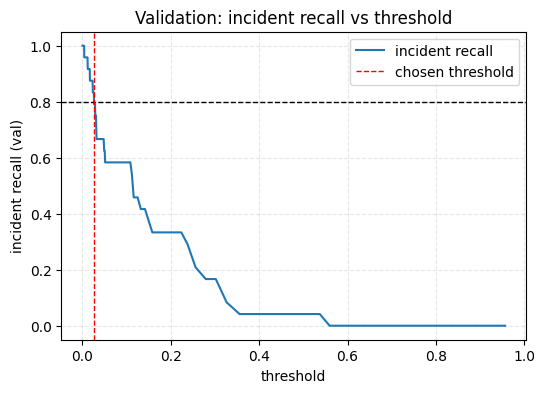

In [32]:
thr_table, threshold = select_threshold_on_val(
    splits=splits,
    final_model_=final_model,
    target_incident_recall=TARGET_INCIDENT_RECALL,
    grid_size=THRESH_GRID_SIZE,
)

print("Selected threshold (from train-only model on val):", threshold)

# Show incident recall vs threshold trade-off curve
plt.figure(figsize=(6, 4))
plt.plot(thr_table["threshold"], thr_table["incident_recall"], label="incident recall")
plt.axhline(TARGET_INCIDENT_RECALL, color="black", linestyle="--", lw=1)
plt.axvline(threshold, color="red", linestyle="--", lw=1, label="chosen threshold")
plt.xlabel("threshold")
plt.ylabel("incident recall (val)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.title("Validation: incident recall vs threshold")
plt.show()

## Validation trade-off curve (incident recall vs. threshold)

The plot shows how incident-level recall changes as the alert threshold grows.
- Lower thresholds lead to more alerts and higher recall, but with many false alerts
- Higher thresholds lead to fewer alerts and lower recall

The dashed horizontal line is the target incident recall, and the vertical red line is the chosen threshold.

The selected threshold is:
- `threshold ≈ 0.025855`

This is a very low threshold, suggesting the model’s predicted probabilities are often small even for positive windows, which typically increases alert volume and will hurt precision.

In [33]:
def predict_per_machine(
    model: Any,
    splits: dict[str, MachineEvalSplit],
    which: str,
) -> dict[str, dict[str, np.ndarray]]:
    out: dict[str, dict[str, np.ndarray]] = {}
    for name, s in splits.items():
        if which == "val":
            X, y, t = s.X_val, s.y_val, s.t_val
        elif which == "test":
            X, y, t = s.X_te, s.y_te, s.t_te
        else:
            raise ValueError("which must be 'val' or 'test'")
        p = model.predict_proba(X)[:, 1].astype(float)
        out[name] = {"proba": p, "y": y.astype(int), "t": t.astype(int)}
    return out


test_pred_final = predict_per_machine(final_model, splits, which="test")

te_proba_all = np.concatenate([v["proba"] for v in test_pred_final.values()], axis=0)
te_y_all = np.concatenate([v["y"] for v in test_pred_final.values()], axis=0)

print("Final model test AP (window-level):", average_precision_score(te_y_all, te_proba_all))

Final model test AP (window-level): 0.5743099696460452


In [34]:
def window_metrics(y_true: np.ndarray, proba: np.ndarray, thr: float) -> dict[str, Any]:
    yhat = (proba >= thr).astype(int)
    return {
        "ap": float(average_precision_score(y_true, proba)),
        "precision": float(precision_score(y_true, yhat, zero_division=0)),
        "recall": float(recall_score(y_true, yhat, zero_division=0)),
        "cm": confusion_matrix(y_true, yhat, labels=[0, 1]),
    }


def group_episodes(times: np.ndarray, max_gap: int = 1) -> list[tuple[int, int]]:
    if len(times) == 0:
        return []
    times = np.sort(times.astype(int))
    eps: list[tuple[int, int]] = []
    s = int(times[0])
    e = int(times[0])
    for t in times[1:]:
        t = int(t)
        if t <= e + max_gap:
            e = t
        else:
            eps.append((s, e))
            s, e = t, t
    eps.append((s, e))
    return eps


def episode_precision(
    y_true: np.ndarray,
    proba: np.ndarray,
    t_pred: np.ndarray,
    thr: float,
    max_gap: int = 1,
) -> dict[str, float]:
    alert_times = t_pred[proba >= thr]
    episodes = group_episodes(alert_times, max_gap=max_gap)

    idx_by_time = {int(t): i for i, t in enumerate(t_pred)}
    tp = 0
    fp = 0
    for (a, b) in episodes:
        idxs = [idx_by_time[t] for t in range(a, b + 1) if t in idx_by_time]
        if not idxs:
            continue
        if bool(np.any(y_true[idxs] == 1)):
            tp += 1
        else:
            fp += 1

    n = len(episodes)
    return {
        "n_episodes": float(n),
        "tp_episodes": float(tp),
        "fp_episodes": float(fp),
        "episode_precision": float(tp / n) if n > 0 else float("nan"),
    }


# pooled window-level metrics
pooled_win = window_metrics(te_y_all, te_proba_all, threshold)
print("\nPooled TEST window-level metrics @ threshold")
print({k: v for k, v in pooled_win.items() if k != "cm"})
print("cm:\n", pooled_win["cm"])

# per-machine table with incident-level recall + lead time
rows = []
lead_all: list[int] = []
inc_total = 0
inc_caught = 0

for name, s in splits.items():
    p = test_pred_final[name]["proba"]
    y = test_pred_final[name]["y"]
    t = test_pred_final[name]["t"]

    inc = incident_level_eval_strict(
        split=s,
        proba=p,
        t_pred=t,
        threshold=threshold,
        which="test",
        horizon=H,
    )
    epi = episode_precision(y_true=y, proba=p, t_pred=t, thr=threshold)

    inc_total += inc.n_incidents
    inc_caught += inc.n_caught
    lead_all.extend(inc.lead_times)

    w = window_metrics(y, p, threshold)

    rows.append(
        {
            "machine": name,
            "n_windows": int(len(y)),
            "pos_rate": float(y.mean()),
            "ap": float(w["ap"]),
            "win_precision": float(w["precision"]),
            "win_recall": float(w["recall"]),
            "n_incidents": int(inc.n_incidents),
            "inc_caught": int(inc.n_caught),
            "inc_recall": float(inc.recall),
            "lead_mean": float(np.mean(inc.lead_times)) if inc.lead_times else float("nan"),
            "lead_median": float(np.median(inc.lead_times)) if inc.lead_times else float("nan"),
            **epi,
        }
    )

per_machine_report = pd.DataFrame(rows).sort_values(
    ["inc_recall", "machine"],
    ascending=[True, True],
)

pooled_inc_recall = float(inc_caught / inc_total) if inc_total > 0 else float("nan")
print("\nPooled TEST incident-level recall:", pooled_inc_recall)
print("Incidents:", inc_total, "caught:", inc_caught)
print(
    "Lead time (caught only): mean=",
    float(np.mean(lead_all)) if lead_all else float("nan"),
    "median=",
    float(np.median(lead_all)) if lead_all else float("nan"),
)

display(per_machine_report)


Pooled TEST window-level metrics @ threshold
{'ap': 0.5743099696460452, 'precision': 0.20707139300104124, 'recall': 0.8930105427567356}
cm:
 [[35399 17515]
 [  548  4574]]

Pooled TEST incident-level recall: 0.6571428571428571
Incidents: 35 caught: 23
Lead time (caught only): mean= 3.5217391304347827 median= 5.0


,machine,n_windows,pos_rate,ap,win_precision,win_recall,n_incidents,inc_caught,inc_recall,lead_mean,lead_median,n_episodes,tp_episodes,fp_episodes,episode_precision
2,machine-1-3,7076,0.057236,0.293341,0.166667,0.486420,4,0,0.000000,NaN,NaN,101.0,10.0,91.0,0.099010
3,machine-1-4,7078,0.050721,0.393678,0.234020,0.601671,6,2,0.333333,2.500000,2.5,98.0,16.0,82.0,0.163265
7,machine-1-8,7075,0.025159,0.397478,0.069262,0.859551,6,3,0.500000,3.333333,5.0,481.0,7.0,474.0,0.014553
1,machine-1-2,7074,0.042692,0.218560,0.071393,0.950331,4,3,0.750000,5.000000,5.0,306.0,5.0,301.0,0.016340
0,machine-1-1,8509,0.065225,0.413760,0.267296,0.765766,4,4,1.000000,1.250000,1.5,89.0,7.0,82.0,0.078652
4,machine-1-5,7077,0.003391,0.020218,0.009665,0.541667,2,2,1.000000,1.000000,1.0,322.0,4.0,318.0,0.012422
5,machine-1-6,7072,0.454044,0.945712,0.469349,0.999066,6,6,1.000000,4.833333,5.0,55.0,5.0,50.0,0.090909
6,machine-1-7,7075,0.012438,0.691295,0.018821,0.852273,3,3,1.000000,5.000000,5.0,330.0,5.0,325.0,0.015152


The pooled test results along with the confusion matrix confirm the low precision problem. There is 3x False Positives compared to True Positives. The per-machine results show that on most machines, the model has low AP and/or poor incident recall, but on machine 6, it performed better then average. Incident-level recall is well below the 0.80 validation target, indicating a possible distribution shift or that validation threshold tuning did not generalize perfectly to test.

## Feature importance
This function looks for:
- Top engineered features
- Top base metrics for features 
- Top statistics for features 

Disclaimer:

Impurity importance can be biased toward high-variance / high-cardinality features. The results should be treated as rough indicators, not a definitive explanation.

In [35]:
def engineered_feature_names(base_cols: list[str]) -> list[str]:
    return (
        [f"{c}__mean" for c in base_cols]
        + [f"{c}__std" for c in base_cols]
        + [f"{c}__delta" for c in base_cols]
        + [f"{c}__z" for c in base_cols]
    )


ENG_FEATURES = engineered_feature_names(any_split.feature_cols)


def feature_importance_tables(
    rf: RandomForestClassifier,
    engineered_names: list[str],
    top_n: int = 30,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if not hasattr(rf, "feature_importances_"):
        raise ValueError("Model has no feature_importances_")

    imp = rf.feature_importances_.astype(float)
    s = pd.Series(imp, index=engineered_names).sort_values(ascending=False)
    top = (
        s.head(top_n)
        .rename("importance")
        .reset_index()
        .rename(columns={"index": "feature"})
    )

    base = [f.split("__")[0] for f in engineered_names]
    stat = [f.split("__")[1] for f in engineered_names]
    df = pd.DataFrame({"base": base, "stat": stat, "importance": imp})

    by_base = (
        df.groupby("base")["importance"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )
    by_stat = (
        df.groupby("stat")["importance"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )

    return top, by_base, by_stat


top_imp, by_base, by_stat = feature_importance_tables(
    rf=final_model,
    engineered_names=ENG_FEATURES,
    top_n=25,
)

print("\nTop engineered features (RF impurity importance):")
display(top_imp)

print("\nImportance aggregated by base metric:")
display(by_base.head(20))

print("\nImportance aggregated by statistic type:")
display(by_stat)


Top engineered features (RF impurity importance):


,feature,importance
0,feat_12__mean,0.195445
1,feat_6__mean,0.121788
2,feat_15__mean,0.071428
3,feat_12__std,0.063013
4,feat_19__mean,0.054484
5,feat_23__mean,0.048927
6,feat_8__mean,0.041123
7,feat_33__mean,0.039641
8,feat_11__std,0.025971
9,feat_29__mean,0.021408



Importance aggregated by base metric:


,base,importance
0,feat_12,0.259413
1,feat_6,0.124899
2,feat_15,0.074874
3,feat_23,0.064185
4,feat_8,0.062189
5,feat_19,0.057311
6,feat_33,0.043695
7,feat_11,0.035750
8,feat_29,0.028994
9,feat_22,0.028413



Importance aggregated by statistic type:


,stat,importance
0,mean,0.738151
1,std,0.231667
2,z,0.021746
3,delta,0.008436


## Failure analysis: missed incidents and false positives

The function below visualizes some important incidents that were not caught and false positive episodes.


Missed incidents on TEST count: 12


,machine,start,end,duration
0,machine-1-2,18645,18800,156
1,machine-1-3,17016,17240,225
2,machine-1-3,17660,17715,56
3,machine-1-3,18460,18470,11
4,machine-1-3,22923,23019,97
5,machine-1-4,17630,17717,88
6,machine-1-4,18460,18480,21
7,machine-1-4,22970,23015,46
8,machine-1-4,23218,23220,3
9,machine-1-8,17168,17171,4


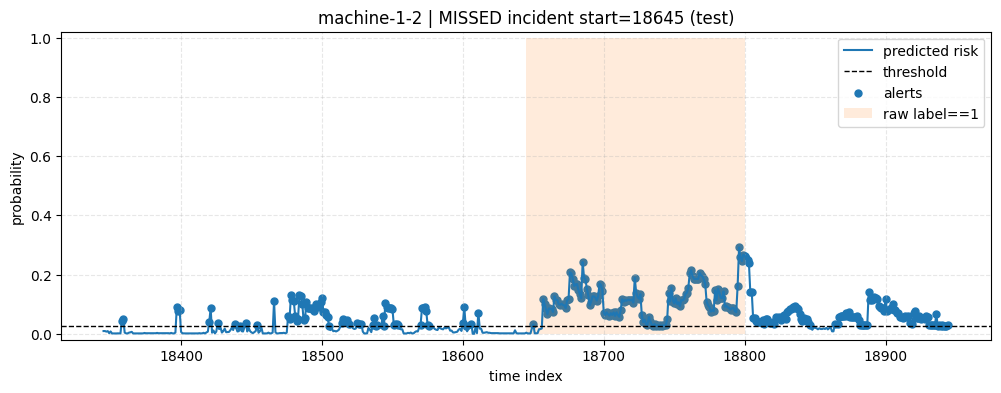

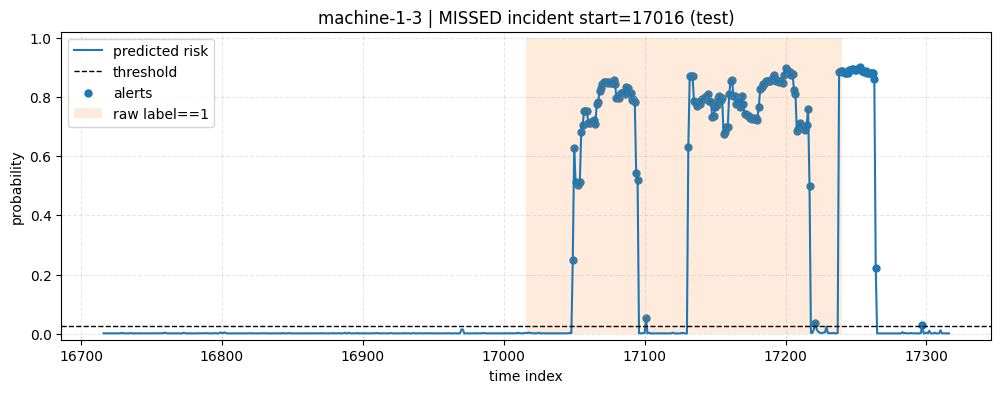

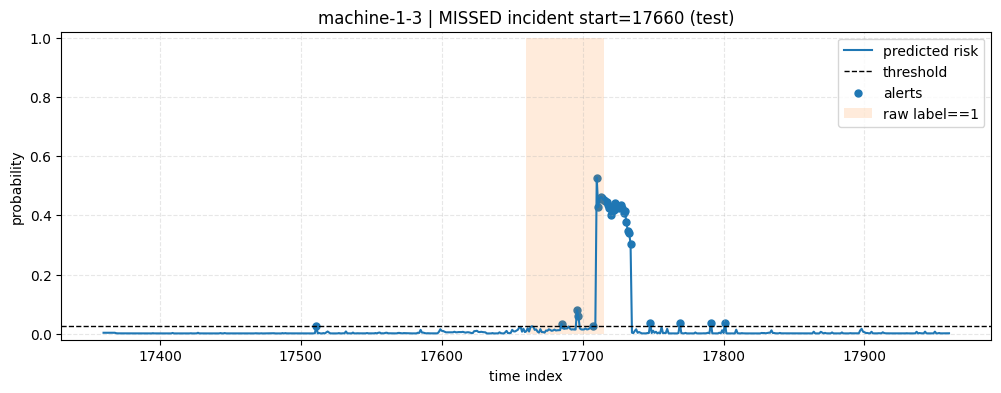

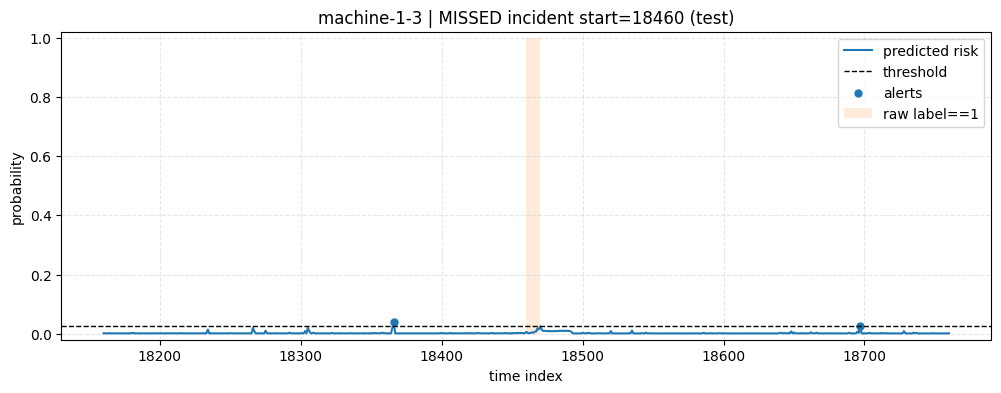

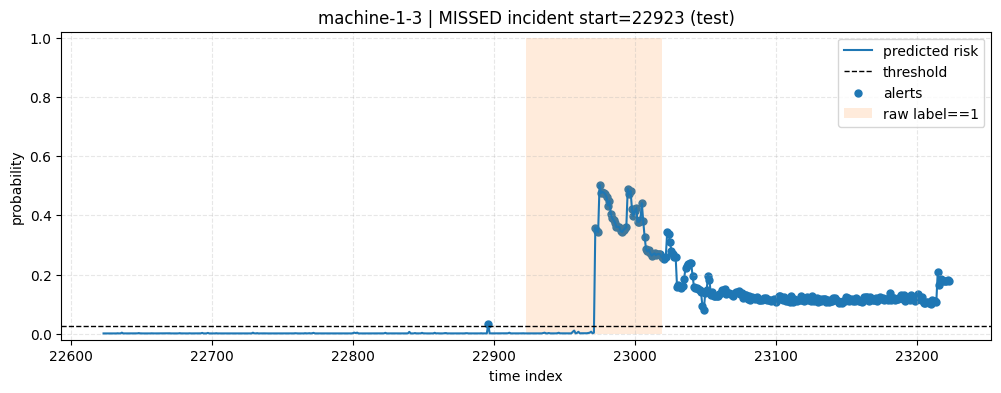


machine-1-1 | top FP episodes (test):


,start,end,duration,max_proba,mean_proba,is_tp_episode
67,26298,26474,177,0.858159,0.329995,False
54,24718,24819,102,0.517843,0.258118,False
55,24836,24890,55,0.390980,0.211240,False


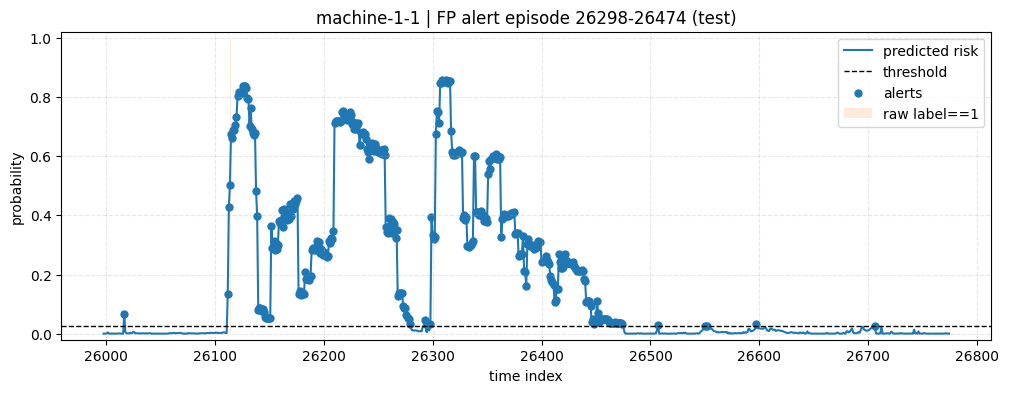

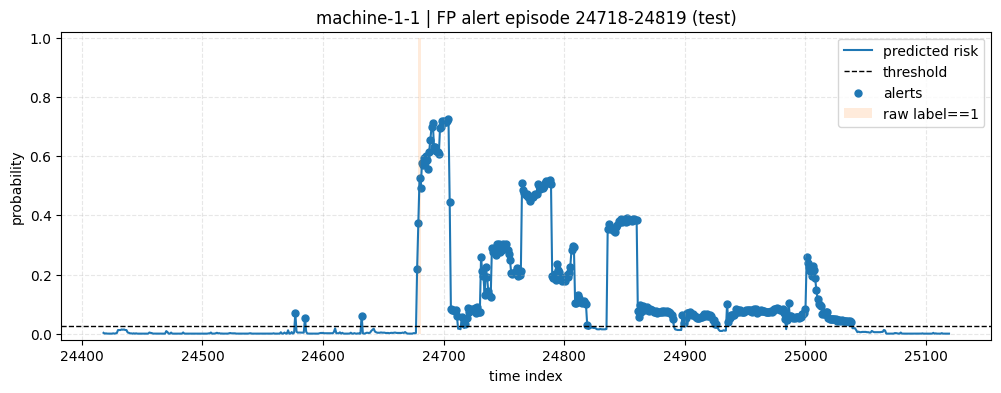

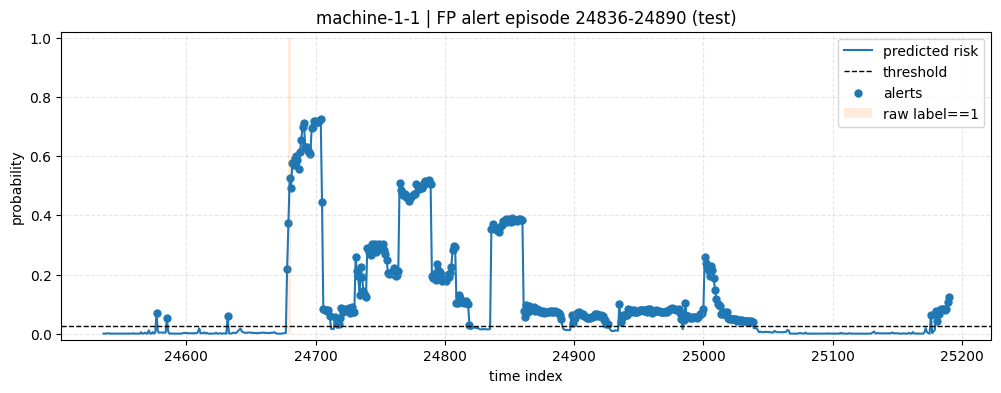


machine-1-2 | top FP episodes (test):


,start,end,duration,max_proba,mean_proba,is_tp_episode
299,23499,23596,98,0.303095,0.108323,False
267,22740,22754,15,0.288264,0.202716,False
137,19906,19951,46,0.283284,0.090416,False


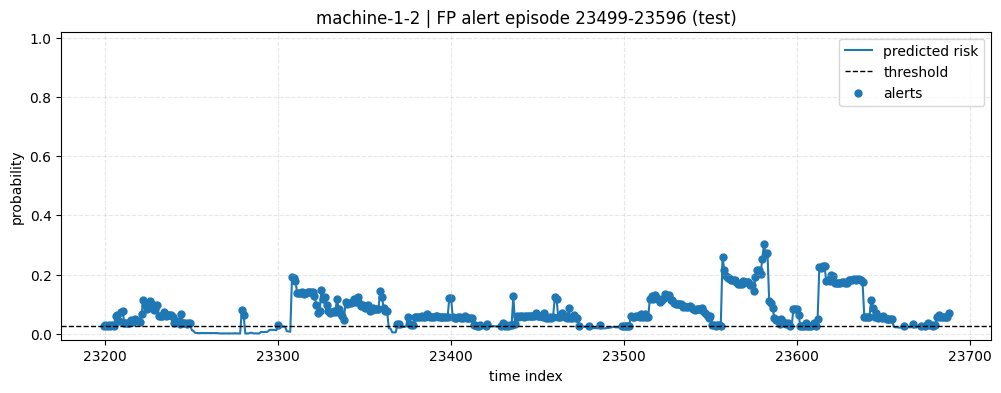

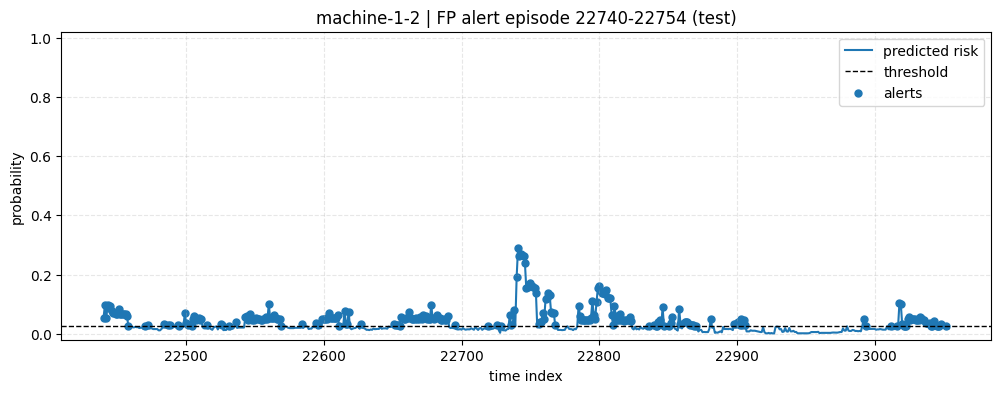

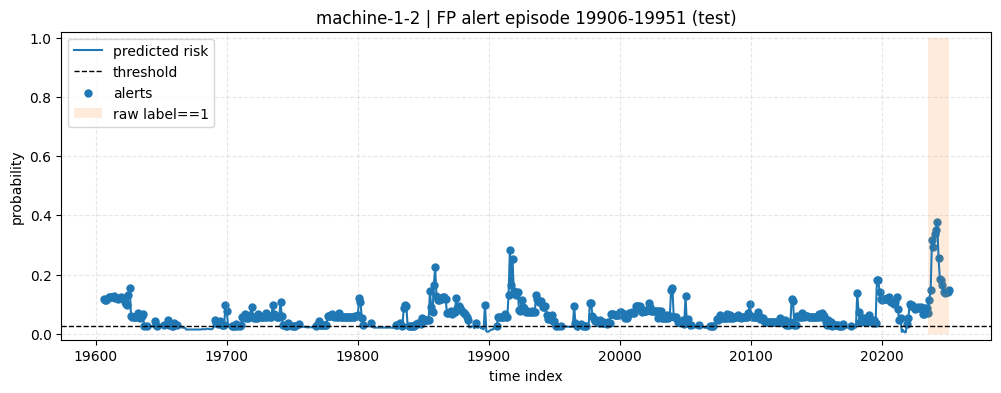

In [36]:
def plot_timeline(
    split: MachineEvalSplit,
    proba: np.ndarray,
    t_pred: np.ndarray,
    threshold_: float,
    t0: int,
    t1: int,
    title: str,
):
    labels = split.df["label"].to_numpy(dtype=int)

    mask = (t_pred >= t0) & (t_pred <= t1)
    t_plot = t_pred[mask]
    p_plot = proba[mask]

    plt.figure(figsize=(12, 4))
    plt.plot(t_plot, p_plot, lw=1.5, label="predicted risk")
    plt.axhline(threshold_, color="black", linestyle="--", lw=1, label="threshold")

    # alert markers
    alert_t = t_plot[p_plot >= threshold_]
    if len(alert_t) > 0:
        plt.scatter(
            alert_t,
            p_plot[p_plot >= threshold_],
            s=25,
            label="alerts",
        )

    # raw incident shading
    raw_t = np.arange(max(0, t0), min(len(labels), t1 + 1))
    raw_y = labels[raw_t]
    if raw_y.sum() > 0:
        plt.fill_between(
            raw_t,
            0,
            1,
            where=raw_y.astype(bool),
            alpha=0.15,
            step="pre",
            label="raw label==1",
        )

    plt.title(title)
    plt.xlabel("time index")
    plt.ylabel("probability")
    plt.ylim(-0.02, 1.02)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend()
    plt.show()


def collect_missed_incidents_test(
    splits: dict[str, MachineEvalSplit],
    pred: dict[str, dict[str, np.ndarray]],
    thr: float,
) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for name, s in splits.items():
        p = pred[name]["proba"]
        t = pred[name]["t"]
        inc = incident_level_eval_strict(
            split=s,
            proba=p,
            t_pred=t,
            threshold=thr,
            which="test",
            horizon=H,
        )
        for (a, b) in inc.missed:
            rows.append(
                {
                    "machine": name,
                    "start": int(a),
                    "end": int(b),
                    "duration": int(b - a + 1),
                }
            )
    if not rows:
        return pd.DataFrame(columns=["machine", "start", "end", "duration"])
    return pd.DataFrame(rows).sort_values(["machine", "start"]).reset_index(drop=True)


missed_df = collect_missed_incidents_test(splits, test_pred_final, threshold)
print("\nMissed incidents on TEST count:", len(missed_df))
display(missed_df.head(20))

# Plot a few missed incidents
for _, r in missed_df.head(5).iterrows():
    name = str(r["machine"])
    s = splits[name]
    p = test_pred_final[name]["proba"]
    t = test_pred_final[name]["t"]

    start = int(r["start"])
    t0 = max(0, start - PLOT_CONTEXT)
    t1 = min(len(s.df) - 1, start + PLOT_CONTEXT)

    plot_timeline(
        split=s,
        proba=p,
        t_pred=t,
        threshold_=threshold,
        t0=t0,
        t1=t1,
        title=f"{name} | MISSED incident start={start} (test)",
    )


def false_alert_episodes_test(
    split: MachineEvalSplit,
    proba: np.ndarray,
    t_pred: np.ndarray,
    thr: float,
    max_gap: int = 1,
) -> pd.DataFrame:
    alert_times = t_pred[proba >= thr]
    episodes = group_episodes(alert_times, max_gap=max_gap)

    idx_by_time = {int(t): i for i, t in enumerate(t_pred)}
    rows: list[dict[str, Any]] = []
    y_window = split.y_te.astype(int)

    for (a, b) in episodes:
        idxs = [idx_by_time[t] for t in range(a, b + 1) if t in idx_by_time]
        if not idxs:
            continue
        is_tp = bool(np.any(y_window[idxs] == 1))
        rows.append(
            {
                "start": int(a),
                "end": int(b),
                "duration": int(b - a + 1),
                "max_proba": float(np.max(proba[idxs])),
                "mean_proba": float(np.mean(proba[idxs])),
                "is_tp_episode": bool(is_tp),
            }
        )

    if not rows:
        return pd.DataFrame(
            columns=[
                "start",
                "end",
                "duration",
                "max_proba",
                "mean_proba",
                "is_tp_episode",
            ]
        )

    return pd.DataFrame(rows).sort_values(
        ["is_tp_episode", "max_proba"],
        ascending=[True, False],
    )


# Plot top FP episodes for a couple of machines
for name in sorted(splits.keys())[:2]:
    s = splits[name]
    p = test_pred_final[name]["proba"]
    t = test_pred_final[name]["t"]

    epi_df = false_alert_episodes_test(s, p, t, threshold, max_gap=1)
    fp = epi_df[epi_df["is_tp_episode"] == False].head(3)  # noqa: E712

    print(f"\n{name} | top FP episodes (test):")
    display(fp)

    for _, r in fp.iterrows():
        start = int(r["start"])
        end = int(r["end"])
        t0 = max(0, start - PLOT_CONTEXT)
        t1 = min(len(s.df) - 1, end + PLOT_CONTEXT)

        plot_timeline(
            split=s,
            proba=p,
            t_pred=t,
            threshold_=threshold,
            t0=t0,
            t1=t1,
            title=f"{name} | FP alert episode {start}-{end} (test)",
        )

In [37]:
OUT_DIR = ART_DIR / "evaluation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

per_machine_report.to_csv(OUT_DIR / "per_machine_test_report.csv", index=False)
thr_table.to_csv(OUT_DIR / "threshold_sweep_val_strict.csv", index=False)
missed_df.to_csv(OUT_DIR / "missed_incidents_test.csv", index=False)

summary = {
    "W": W,
    "H": H,
    "threshold": float(threshold),
    "target_incident_recall_val": float(TARGET_INCIDENT_RECALL),
    "calib_use_tuned_trees": bool(CALIB_USE_TUNED_TREES),
    "window_metrics_test": {
        "ap": pooled_win["ap"],
        "precision": pooled_win["precision"],
        "recall": pooled_win["recall"],
        "cm": pooled_win["cm"].tolist(),
    },
    "incident_metrics_test_strict": {
        "incident_recall": pooled_inc_recall,
        "n_incidents": int(inc_total),
        "n_caught": int(inc_caught),
        "lead_time_mean": float(np.mean(lead_all)) if lead_all else None,
        "lead_time_median": float(np.median(lead_all)) if lead_all else None,
    },
}

with open(OUT_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("\nSaved evaluation outputs to:", OUT_DIR.resolve())


Saved evaluation outputs to: /Users/peterbrenkus/Desktop/projekty/cloud_metrics_predictions/artifacts/final_rf_group1/evaluation


## Save evaluation artifacts

I save the following evaluation outputs for future reference:
- per-machine test report CSV
- validation threshold sweep table CSV
- missed incidents CSV
- a summary JSON containing key metrics and chosen threshold

# Conclusion

## Summary of performance

Validation:
- Threshold selected to target incident recall on validation:
  - `threshold ≈ 0.025855`

Pooled window-level test at chosen threshold:
- AP ≈ 0.5743
- precision ≈ 0.2071
- recall ≈ 0.8930
- confusion matrix:
  - TN = 35399, FP = 17515
  - FN = 548,   TP = 4574

Pooled incident-level test:
- incidents = 35, caught = 23
- incident recall ≈ 0.6571
- lead time (caught only): mean ≈ 3.52, median = 5.0
- missed incidents: 12

The operating point needed for high window recall yields many false positives, and the incident-level recall on test is meaningfully below the validation target.

## Possible future changes / enhancements

Without retraining the RF, a possible improvement would be to add decision logic beyond a single threshold:
- require persistence (e.g., alert only if `p >= thr` for \(k\) consecutive windows)
- hysteresis thresholds (different `thr_on` / `thr_off`)
- cooldown after an episode to reduce repeated alerts


With retraining, possible improvements could be:
- richer time-series features (trends, quantiles, slopes, EWMA, ...)
- time-aware cross-validation / evaluation to reduce threshold overfitting to one validation block
- possibly a different model